Cryptocurrency Market Segmentation using Unsupervised Learning

Instead of just clustering,I included:

✔ Feature Engineering
✔ Scaling
✔ Elbow Method
✔ K-Means Clustering
✔ PCA (Dimensionality Reduction)
✔ Cluster Interpretation
✔ Business Insights

In [2]:
# Upload file from your system
from google.colab import files
uploaded = files.upload()

# Import pandas
import pandas as pd

# Load dataset
data = pd.read_csv("crypto_data.csv")

# Convert Date column
data['Date'] = pd.to_datetime(data['Date'])

# Set Date as index
data.set_index('Date', inplace=True)

# Preview data
print(data.head())

Saving crypto_data.csv to crypto_data.csv
                            BTC  ETH  BTC_MA50
Date                                          
2013-04-29 23:59:59  144.539993  NaN       NaN
2013-04-30 23:59:59  139.000000  NaN       NaN
2013-05-01 23:59:59  116.989998  NaN       NaN
2013-05-02 23:59:59  105.209999  NaN       NaN
2013-05-03 23:59:59   97.750000  NaN       NaN


FEATURE ENGINEERING

In [3]:
returns = data.pct_change().dropna()

features = pd.DataFrame()

features['Mean_Return'] = returns.mean()
features['Volatility'] = returns.std()
features['Max_Return'] = returns.max()
features['Min_Return'] = returns.min()

print(features)

          Mean_Return  Volatility  Max_Return  Min_Return
BTC          0.003059    0.039775    0.252472   -0.371695
ETH          0.005670    0.063036    0.507323   -0.423472
BTC_MA50     0.002287    0.006424    0.031693   -0.018070


FEATURE SCALING

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

ELBOW METHOD

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

APPLY K-MEANS

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
features['Cluster'] = kmeans.fit_predict(scaled_features)

print(features)

          Mean_Return  Volatility  Max_Return  Min_Return  Cluster
BTC          0.003059    0.039775    0.252472   -0.371695        2
ETH          0.005670    0.063036    0.507323   -0.423472        0
BTC_MA50     0.002287    0.006424    0.031693   -0.018070        1


PCA

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

VISUALIZATION

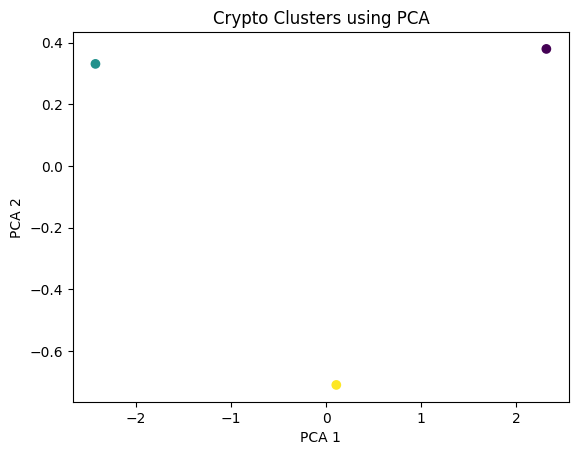

In [11]:
import matplotlib.pyplot as plt

plt.scatter(pca_features[:,0], pca_features[:,1],
            c=features['Cluster'], cmap='viridis')

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Crypto Clusters using PCA")
plt.show()

INTERPRET CLUSTERS

In [12]:
print(features.groupby('Cluster').mean())

         Mean_Return  Volatility  Max_Return  Min_Return
Cluster                                                 
0           0.005670    0.063036    0.507323   -0.423472
1           0.002287    0.006424    0.031693   -0.018070
2           0.003059    0.039775    0.252472   -0.371695
